In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

In [5]:
%matplotlib inline

In [6]:
df = pd.read_csv("/Users/senuja/Jupyter Notebook/Video_Game_Sales_Predictor/data/cleaned/3. Scaling/Scaling(Frequency).csv")

In [7]:
df.head()

,Game Title,Console,Genre,Publisher,Developer,Critic Score,Sales,North American Sales,Japanese Sales,EU Sales,Other Sales,Release Year,Publisher Freq,Developer Freq
0,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,0.933333,1.000000,0.652664,0.464789,1.000000,1.000000,2013,0.088207,0.047945
1,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,0.966667,0.953740,0.620902,0.281690,0.985787,0.967949,2014,0.088207,0.047945
2,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,0.955556,0.794291,0.861680,0.220657,0.557360,0.570513,2002,0.088207,0.047945
3,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,0.677988,0.780512,0.928279,0.028169,0.541117,0.455128,2013,0.088207,0.047945
4,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,0.788889,0.742126,0.633197,0.192488,0.614213,0.782051,2015,1.000000,0.125571


In [8]:
df.dtypes # check data types

Game Title               object
Console                  object
Genre                    object
Publisher                object
Developer                object
Critic Score            float64
Sales                   float64
North American Sales    float64
Japanese Sales          float64
EU Sales                float64
Other Sales             float64
Release Year              int64
Publisher Freq          float64
Developer Freq          float64
dtype: object

In [9]:
# Create decade column
df['Decade'] = (df['Release Year'] // 10) * 10

# Percentages of sales per region 
df['NA Share'] = df['North American Sales'] / df['Sales']
df['EU Share'] = df['EU Sales'] / df['Sales']
df['JP Share'] = df['Japanese Sales'] / df['Sales']
df['Other Share'] = df['Other Sales'] / df['Sales']

# New Game ?
df['Is Recent'] = df['Release Year'].apply(lambda x: 1 if x >= 2015 else 0)

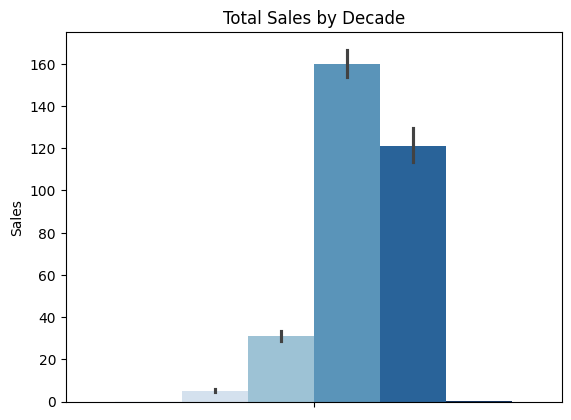

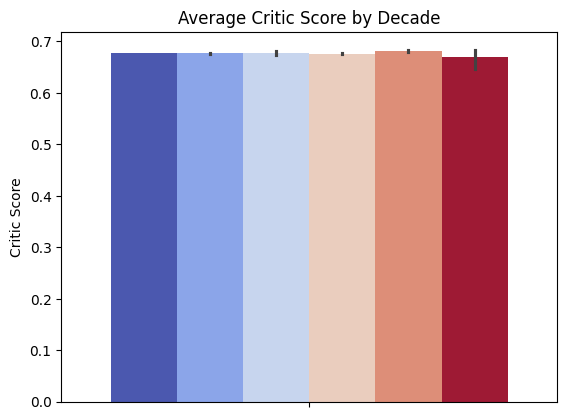

In [10]:
# Check sales trends across decades

sns.barplot(hue="Decade", y="Sales", data=df, estimator="sum", palette="Blues", legend=False)
plt.title("Total Sales by Decade")
plt.show()

sns.barplot(hue="Decade", y="Critic Score", data=df, estimator="mean", palette="coolwarm", legend=False)
plt.title("Average Critic Score by Decade")
plt.show()

In [11]:
df.head()

,Game Title,Console,Genre,Publisher,Developer,Critic Score,Sales,North American Sales,Japanese Sales,EU Sales,Other Sales,Release Year,Publisher Freq,Developer Freq,Decade,NA Share,EU Share,JP Share,Other Share,Is Recent
0,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,0.933333,1.000000,0.652664,0.464789,1.000000,1.000000,2013,0.088207,0.047945,2010,0.652664,1.000000,0.464789,1.000000,0
1,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,0.966667,0.953740,0.620902,0.281690,0.985787,0.967949,2014,0.088207,0.047945,2010,0.651018,1.033601,0.295353,1.014898,0
2,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,0.955556,0.794291,0.861680,0.220657,0.557360,0.570513,2002,0.088207,0.047945,2000,1.084842,0.701708,0.277804,0.718266,0
3,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,0.677988,0.780512,0.928279,0.028169,0.541117,0.455128,2013,0.088207,0.047945,2010,1.189320,0.693285,0.036090,0.583115,0
4,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,0.788889,0.742126,0.633197,0.192488,0.614213,0.782051,2015,1.000000,0.125571,2010,0.853220,0.827640,0.259374,1.053799,1


In [12]:
# Bins and labels
bins = [0, 0.3, 0.7, 1.0]          # cut points
labels = ["Low", "Medium", "High"] # category names

# New Game Quality column 
df["Game Quality"] = pd.cut(df["Critic Score"], bins=bins, labels=labels, include_lowest=True)

# Label Encode categories as integers
encoding_map = {"Low": 0, "Medium": 1, "High": 2}
df["Game Quality Encoded"] = df["Game Quality"].map(encoding_map)

# check
print(df[["Critic Score", "Game Quality", "Game Quality Encoded"]].head(20))

    Critic Score Game Quality Game Quality Encoded
0       0.933333         High                    2
1       0.966667         High                    2
2       0.955556         High                    2
3       0.677988       Medium                    1
4       0.788889         High                    2
5       0.855556         High                    2
6       0.866667         High                    2
7       0.977778         High                    2
8       0.822222         High                    2
9       0.777778         High                    2
10      0.944444         High                    2
11      0.788889         High                    2
12      0.866667         High                    2
13      0.944444         High                    2
14      0.855556         High                    2
15      0.811111         High                    2
16      1.000000         High                    2
17      0.877778         High                    2
18      0.944444         High  

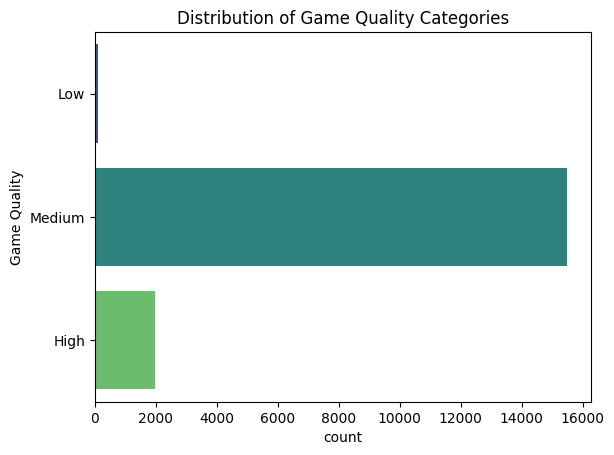

In [13]:
# Distribution of Game Quality

sns.countplot(hue="Game Quality", y="Game Quality", data=df, palette="viridis", legend=False)
plt.title("Distribution of Game Quality Categories")
plt.show()

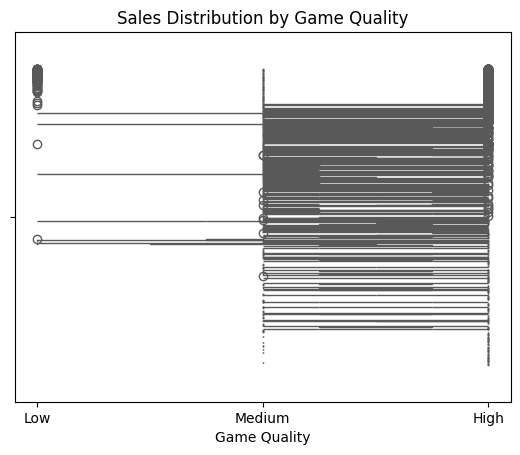

In [14]:
sns.boxplot(x="Game Quality", hue="Sales", data=df, palette="Set2", legend=False)
plt.title("Sales Distribution by Game Quality")
plt.show()

In [15]:
df.to_csv("/Users/senuja/Jupyter Notebook/Video_Game_Sales_Predictor/data/cleaned/4. Feature Engineering/Ft Engineering(Frequency).csv", index=False)